In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/radc/Desktop/dataset_definitivo.csv")
df.head()

,nsocio,codigopostaldomicilio,numeroclub,modalidad,categoria,discapacidad,numeroaccidentesaño,helicoptero,hospitalizacion,target,...,Provincia,TipoAccidente,DescripcionGrado,TamañoGrupo,NResponsables,Entrenamiento,ActividadPersonal,ActividadOrganizada,Festivo,año_accidente
0,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,28043,07.28.012,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 121276 entries, 0 to 121275
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   nsocio                 121276 non-null  int64  
 1   codigopostaldomicilio  121276 non-null  str    
 2   numeroclub             121276 non-null  str    
 3   modalidad              121276 non-null  str    
 4   categoria              121276 non-null  str    
 5   discapacidad           121276 non-null  str    
 6   numeroaccidentesaño    121276 non-null  float64
 7   helicoptero            121276 non-null  float64
 8   hospitalizacion        121276 non-null  float64
 9   target                 121276 non-null  int64  
 10  accidenteshistoricos   121276 non-null  float64
 11  edad                   121276 non-null  int64  
 12  temporada_federado     121276 non-null  int64  
 13  Actividad              17900 non-null   str    
 14  Lugar                  17373 non-null   str    

In [4]:
df.columns # Comienzo con la comprensión de las columnas

Index(['nsocio', 'codigopostaldomicilio', 'numeroclub', 'modalidad',
       'categoria', 'discapacidad', 'numeroaccidentesaño', 'helicoptero',
       'hospitalizacion', 'target', 'accidenteshistoricos', 'edad',
       'temporada_federado', 'Actividad', 'Lugar', 'Provincia',
       'TipoAccidente', 'DescripcionGrado', 'TamañoGrupo', 'NResponsables',
       'Entrenamiento', 'ActividadPersonal', 'ActividadOrganizada', 'Festivo',
       'año_accidente'],
      dtype='str')

In [5]:
df.dtypes # Primero compruebo que tipos son exactamente

nsocio                     int64
codigopostaldomicilio        str
numeroclub                   str
modalidad                    str
categoria                    str
discapacidad                 str
numeroaccidentesaño      float64
helicoptero              float64
hospitalizacion          float64
target                     int64
accidenteshistoricos     float64
edad                       int64
temporada_federado         int64
Actividad                    str
Lugar                        str
Provincia                    str
TipoAccidente                str
DescripcionGrado             str
TamañoGrupo              float64
NResponsables            float64
Entrenamiento             object
ActividadPersonal         object
ActividadOrganizada       object
Festivo                   object
año_accidente            float64
dtype: object

In [6]:
df["nsocio"].duplicated().sum()

np.int64(84317)

In [7]:
df.groupby("nsocio")["temporada_federado"].nunique().describe()

count    36959.000000
mean         3.165372
std          1.967821
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max          6.000000
Name: temporada_federado, dtype: float64

In [8]:
def describe_df(df):

    # Diccionario para almacenar la información de cada columna
    data_dict = {}
    
    # Iterar sobre cada columna del dataframe
    for columna in df.columns:
        # Determinar si la columna es categórica o numérica
        data_type = "categorica" if df[columna].dtype == "object" else "numerica"
        
        # Calcular porcentaje de valores nulos redondeado a 1 decimal
        valores_nulos = round(df[columna].isna().sum() / len(df) * 100, 1)
        
        # Contar valores únicos
        valores_unicos = df[columna].nunique()
        
        # Calcular cardinalidad en porcentaje redondeado a 2 decimales
        cardinalidad_ptg = round(valores_unicos / len(df) * 100, 2)
        
        # Guardar información en el diccionario
        data_dict[columna] = {
            "data_type": data_type,
            "valores_nulos": valores_nulos,
            "valores_unicos": valores_unicos,
            "cardinalidad_ptg": cardinalidad_ptg
        }
    
    # Convertir a dataframe y transponer para tener columnas originales como filas
    return pd.DataFrame(data_dict).T

In [9]:
describe_df(df) # Aqui vemos claramente todas las columnas y vemos que todas o casi todas las de siniestro tienen un gran porcentaje de NaNs (normal)

,data_type,valores_nulos,valores_unicos,cardinalidad_ptg
nsocio,numerica,0.0,36959,30.48
codigopostaldomicilio,numerica,0.0,1635,1.35
numeroclub,numerica,0.0,181,0.15
modalidad,numerica,0.0,15,0.01
categoria,numerica,0.0,10,0.01
discapacidad,numerica,0.0,113,0.09
numeroaccidentesaño,numerica,0.0,4,0.0
helicoptero,numerica,0.0,1,0.0
hospitalizacion,numerica,0.0,2,0.0
target,numerica,0.0,2,0.0


In [10]:
df_model = df.copy()
df_model # Creo una copia para poder deshacerme de las columnas que no nos convienen para el modelado

,nsocio,codigopostaldomicilio,numeroclub,modalidad,categoria,discapacidad,numeroaccidentesaño,helicoptero,hospitalizacion,target,...,Provincia,TipoAccidente,DescripcionGrado,TamañoGrupo,NResponsables,Entrenamiento,ActividadPersonal,ActividadOrganizada,Festivo,año_accidente
0,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,28043,07.28.012,B,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121271,78946,28080,07.28.475,AU,Mayor Mujer,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121272,79253,28045,07.28.370,B,Mayor Mujer,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121273,78924,28016,07.28.000,C,Mayor Mujer,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121274,79882,46007,07.28.000,OT,Mayor VarÃ³n,NO,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
drop_cols = [
    "Actividad",
    "Lugar",
    "Provincia",
    "TipoAccidente",
    "DescripcionGrado",
    "TamañoGrupo",
    "NResponsables",
    "Entrenamiento",
    "ActividadPersonal",
    "ActividadOrganizada",
    "Festivo",
    "año_accidente",
    "hospitalizacion",
    "helicoptero"
]

df_model = df.drop(columns=drop_cols) 


In [12]:
# Como nuestro objetivo es predecir si un federado tendrá un siniestro en el futuro,
# no debemos incluir variables que solo existen cuando el siniestro ya ha ocurrido.

# Estas columnas provienen del dataset de siniestros y tienen un alto porcentaje de NaNs,
# ya que solo contienen información para los federados que han tenido un accidente.

# Si el modelo las utilizara, podría aprender a predecir el target simplemente detectando
# la presencia o ausencia de estos valores, lo que produciría data leakage.

# Por este motivo, eliminamos estas columnas antes de entrenar el modelo.

In [13]:
df_model.head() # Vemos el resultado final y notamos que la columna "categoria" necesita ser simplificada

,nsocio,codigopostaldomicilio,numeroclub,modalidad,categoria,discapacidad,numeroaccidentesaño,target,accidenteshistoricos,edad,temporada_federado
0,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0,0.0,89,2020
1,59794,28232,07.28.000,B,Mayor VarÃ³n,NO,0.0,0,0.0,90,2021
2,3,28043,07.28.012,B,Mayor VarÃ³n,NO,0.0,0,0.0,88,2020
3,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0,0.0,80,2020
4,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0,0.0,81,2021


In [14]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 121276 entries, 0 to 121275
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   nsocio                 121276 non-null  int64  
 1   codigopostaldomicilio  121276 non-null  str    
 2   numeroclub             121276 non-null  str    
 3   modalidad              121276 non-null  str    
 4   categoria              121276 non-null  str    
 5   discapacidad           121276 non-null  str    
 6   numeroaccidentesaño    121276 non-null  float64
 7   target                 121276 non-null  int64  
 8   accidenteshistoricos   121276 non-null  float64
 9   edad                   121276 non-null  int64  
 10  temporada_federado     121276 non-null  int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 10.2 MB


In [15]:
df_model.columns

Index(['nsocio', 'codigopostaldomicilio', 'numeroclub', 'modalidad',
       'categoria', 'discapacidad', 'numeroaccidentesaño', 'target',
       'accidenteshistoricos', 'edad', 'temporada_federado'],
      dtype='str')

In [16]:
df_model["categoria"].unique() # Vemos los valores unicos para transformarlos

<StringArray>
[   'Mayor VarÃ³n',     'Mayor Mujer', 'TÃ©cnico VarÃ³n',  'Ãrbitro Mujer',
 'Ãrbitro VarÃ³n',  'TÃ©cnico Mujer',  'Juvenil VarÃ³n',  'Infantil Mujer',
   'Juvenil Mujer', 'Infantil VarÃ³n']
Length: 10, dtype: str

In [17]:
df_model["categoria"] = (
    df_model["categoria"]
    .str.encode("latin1")
    .str.decode("utf-8")
) # Primero codificamos los caracteres para eliminar los acentos y las tildes

In [18]:
df_model["categoria"].unique()

<StringArray>
[   'Mayor Varón',    'Mayor Mujer',  'Técnico Varón',  'Árbitro Mujer',
  'Árbitro Varón',  'Técnico Mujer',  'Juvenil Varón', 'Infantil Mujer',
  'Juvenil Mujer', 'Infantil Varón']
Length: 10, dtype: str

In [19]:
df_model.groupby("categoria")["edad"].describe() 
# Hacemos un groupby para definir mejor las categorías por edad
# Dividiremos entre niños, jóvenes y adultos

,count,mean,std,min,25%,50%,75%,max
categoria,,,,,,,,
Infantil Mujer,1904.0,9.649160,2.559398,0.0,8.0,10.0,12.00,13.0
Infantil Varón,2378.0,9.596299,2.663299,0.0,8.0,10.0,12.00,13.0
Juvenil Mujer,737.0,15.362280,1.124258,14.0,14.0,15.0,16.00,18.0
Juvenil Varón,1273.0,15.513747,1.115221,14.0,15.0,16.0,17.00,17.0
Mayor Mujer,36429.0,50.654232,13.489542,18.0,41.0,51.0,61.00,89.0
Mayor Varón,76142.0,51.096648,13.749852,15.0,42.0,51.0,62.00,90.0
Técnico Mujer,201.0,43.114428,10.232392,22.0,37.0,43.0,51.00,66.0
Técnico Varón,2068.0,48.286267,12.086139,19.0,40.0,48.0,56.25,86.0
Árbitro Mujer,45.0,56.044444,6.310005,46.0,52.0,56.0,59.00,71.0


In [20]:
def grupo_persona(row): # Creamos una función manteniendo categorias por edad y sexo
    edad = row["edad"]
    cat = row["categoria"]
    
    if "Mujer" in cat:
        sexo = "Mujer"
    else:
        sexo = "Hombre"
    
    if edad < 14:
        return f"Niño/a {sexo}"
    elif edad < 18:
        return f"Juvenil {sexo}"
    else:
        return sexo

In [21]:
df_model["grupo_persona"] = df_model.apply(grupo_persona, axis=1) # Aplicamos la función para crear una nueva columna con las categorías simplificadas

In [22]:
df_model["grupo_persona"].value_counts() # Vemos el resultado final de la nueva columna y comprobamos que tiene sentido con los datos originales

grupo_persona
Hombre            78308
Mujer             36676
Niño/a Hombre      2378
Niño/a Mujer       1904
Juvenil Hombre     1274
Juvenil Mujer       736
Name: count, dtype: int64

In [23]:
df_model # Mostramos el dataframe final para comprobar que todo tiene sentido

,nsocio,codigopostaldomicilio,numeroclub,modalidad,categoria,discapacidad,numeroaccidentesaño,target,accidenteshistoricos,edad,temporada_federado,grupo_persona
0,59794,28232,07.28.000,B,Mayor Varón,NO,0.0,0,0.0,89,2020,Hombre
1,59794,28232,07.28.000,B,Mayor Varón,NO,0.0,0,0.0,90,2021,Hombre
2,3,28043,07.28.012,B,Mayor Varón,NO,0.0,0,0.0,88,2020,Hombre
3,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0,0.0,80,2020,Mujer
4,12,28028,07.28.060,A,Mayor Mujer,NO,0.0,0,0.0,81,2021,Mujer
...,...,...,...,...,...,...,...,...,...,...,...,...
121271,78946,28080,07.28.475,AU,Mayor Mujer,NO,0.0,0,0.0,28,2025,Mujer
121272,79253,28045,07.28.370,B,Mayor Mujer,NO,0.0,0,0.0,34,2025,Mujer
121273,78924,28016,07.28.000,C,Mayor Mujer,NO,0.0,0,0.0,22,2025,Mujer
121274,79882,46007,07.28.000,OT,Mayor Varón,NO,0.0,0,0.0,29,2025,Hombre


In [24]:
df_model = df_model.drop(columns="categoria") # Nos deshacemos de la columna original que ya no necesitamos

In [25]:
df_model.head(5) # Vemos el head y comprabamos que todo sigue teniendo sentido

,nsocio,codigopostaldomicilio,numeroclub,modalidad,discapacidad,numeroaccidentesaño,target,accidenteshistoricos,edad,temporada_federado,grupo_persona
0,59794,28232,07.28.000,B,NO,0.0,0,0.0,89,2020,Hombre
1,59794,28232,07.28.000,B,NO,0.0,0,0.0,90,2021,Hombre
2,3,28043,07.28.012,B,NO,0.0,0,0.0,88,2020,Hombre
3,12,28028,07.28.060,A,NO,0.0,0,0.0,80,2020,Mujer
4,12,28028,07.28.060,A,NO,0.0,0,0.0,81,2021,Mujer


In [26]:
# Hacemos un EDA para ver la distribución del target

In [27]:
df_model["target"].value_counts() 
df_model["target"].value_counts(normalize=True)

target
0    0.953107
1    0.046893
Name: proportion, dtype: float64

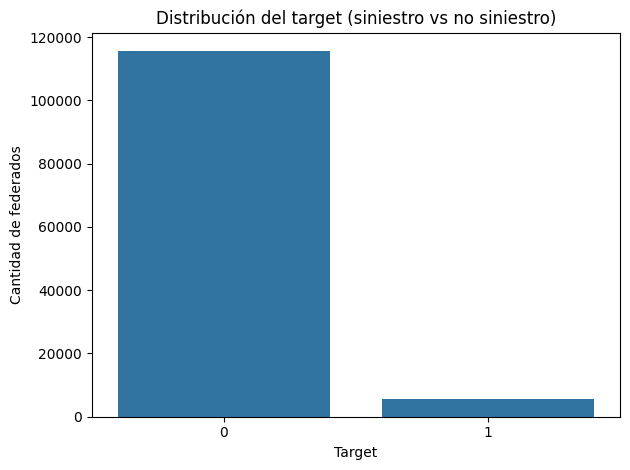

In [28]:
sns.countplot(x="target", data=df_model) 
plt.title("Distribución del target (siniestro vs no siniestro)")
plt.xlabel("Target")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();

# Vemos la distribucion del target (siniestro vs no siniestro)

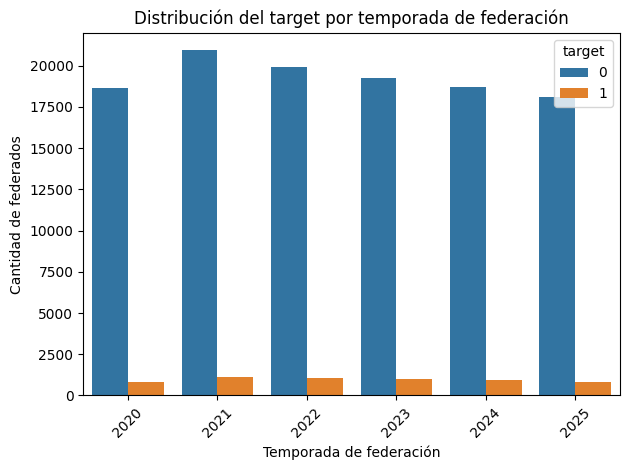

In [29]:
sns.countplot(x="temporada_federado", hue="target", data=df_model)
plt.xticks(rotation=45)
plt.title("Distribución del target por temporada de federación")
plt.xlabel("Temporada de federación")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();
 
# Vemos la distribución del target según  la temporada de federación
# Del 2020 al 2021 hay un aumento de sinietros, seguramente por la pandemia y el aumento de actividades al aire libre
# En general se mantiene una proporción bastante similar de siniestros en cada temporada

In [30]:
df_model.groupby("temporada_federado")["target"].mean()

temporada_federado
2020    0.040940
2021    0.050408
2022    0.051594
2023    0.048146
2024    0.047081
2025    0.042158
Name: target, dtype: float64

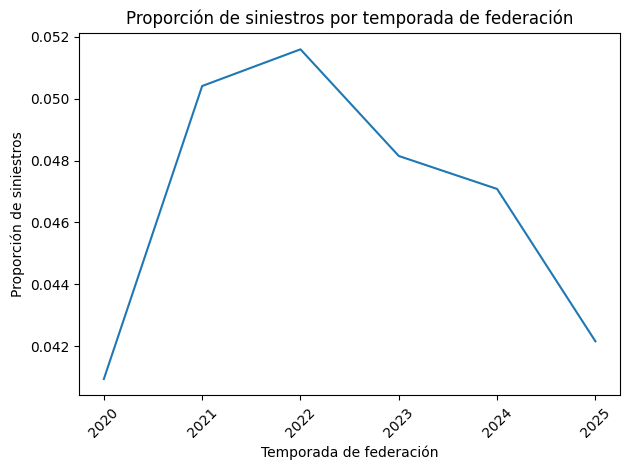

In [31]:
df_model.groupby("temporada_federado")["target"].mean().plot();
plt.xticks(rotation=45)
plt.title("Proporción de siniestros por temporada de federación")
plt.xlabel("Temporada de federación")
plt.ylabel("Proporción de siniestros")
plt.tight_layout()
plt.show();

# Agrupamos por temporada_federado y calculamos la media del target, que representa la proporción de siniestros en cada número de temporadas federado.
# Observamos un patrón creciente y luego decreciente. Esto puede deberse a varios factores,
# como diferencias en el número de observaciones por temporada o cambios en la población de federados
# Por lo que no se puede atribuir directamente a una única causa.

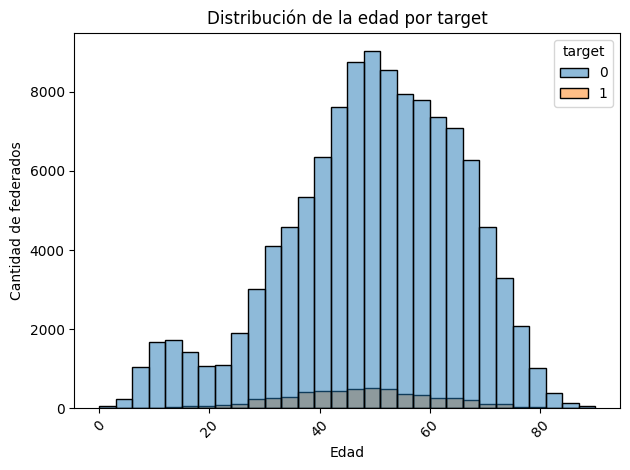

In [32]:
sns.histplot(data=df_model, x="edad", hue="target", bins=30)
plt.xticks(rotation=45)
plt.title("Distribución de la edad por target")
plt.xlabel("Edad")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();

# Los siniestros parecen ser bastante proporcionales con el numero de federados por edad (más federados por edad = más siniestros por esa edad)

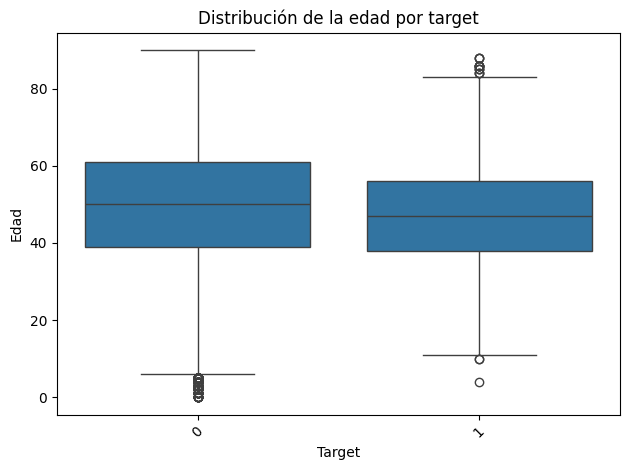

In [33]:
sns.boxplot(x="target", y="edad", data=df_model)
plt.xticks(rotation=45)
plt.title("Distribución de la edad por target")
plt.xlabel("Target")
plt.ylabel("Edad")
plt.tight_layout()
plt.show();

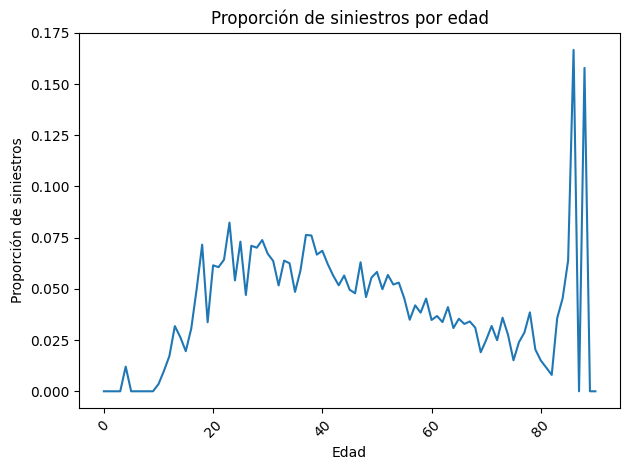

In [34]:
df_model.groupby("edad")["target"].mean().plot()
plt.xticks(rotation=45)
plt.title("Proporción de siniestros por edad")
plt.xlabel("Edad")
plt.ylabel("Proporción de siniestros")
plt.tight_layout()
plt.show();

In [35]:
# Podemos ver que el número de siniestros por edad sube con adolescentes hasta un pico en los 20s y luego se mantiene 
# A medida que sube la edad, los siniestros van bajando hasta que llegamos a los 80s, donde hay unos picos abruptos muy altos
# Los polos de edad seguramente sean proporcionales con el número de federados en esas edades
# Casi ningun niño tiene siniestros, lo cual es lógico porque no suelen hacer actividades de riesgo
# Los mayores de 80 debido a que son pocos, cualquiera que tenga un siniestro va a representar un gran porcentaje de siniestros en esa edad, lo cual explica los picos abruptos 

In [36]:
g = df.groupby("edad")["target"].agg(["mean","count"])

g.head()

,mean,count
edad,,
0,0.000000,12
1,0.000000,20
2,0.000000,23
3,0.000000,32
4,0.012048,83


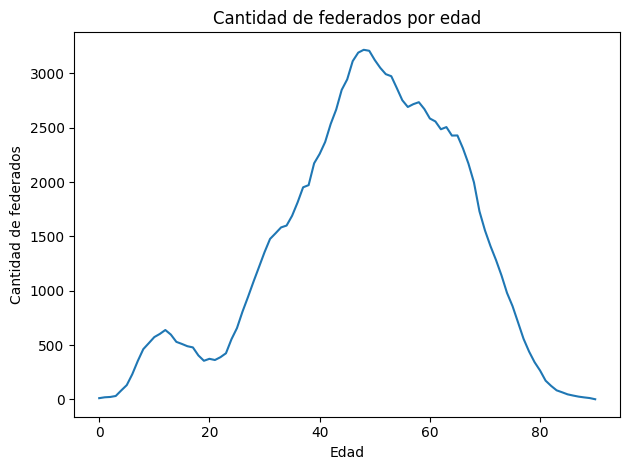

In [37]:
# Graficamos el número de registros por edad
# Esto nos permite ver si hay pocas observaciones en edades altas

g["count"].plot(title="Número de federados por edad")
plt.title("Cantidad de federados por edad")
plt.xlabel("Edad")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();

<Axes: xlabel='edad'>

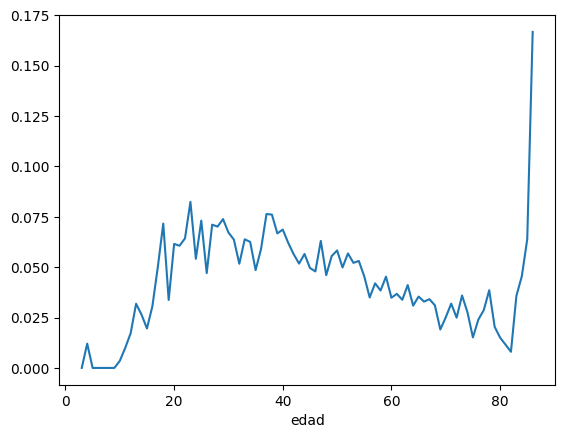

In [38]:
# Eliminamos edades con pocos registros para evitar ruido estadístico
# Con pocas observaciones, un solo siniestro puede generar picos grandes

g = df.groupby("edad")["target"].agg(["mean","count"])

g2 = g[g["count"] > 30]

g2["mean"].plot()

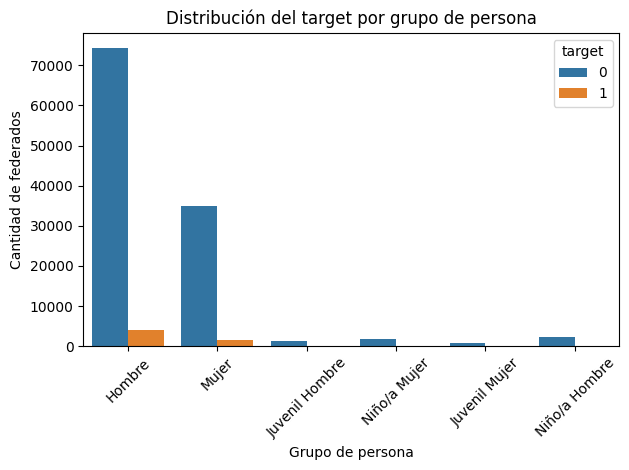

In [39]:
sns.countplot(x="grupo_persona", hue="target", data=df_model)
plt.xticks(rotation=45)
plt.title("Distribución del target por grupo de persona")
plt.xlabel("Grupo de persona")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();

In [40]:
df_model.groupby("modalidad")["target"].mean().sort_values()

modalidad
B Comp.    0.000000
E Comp.    0.000000
B7         0.010811
A6         0.013333
A          0.015629
B6         0.016541
AU         0.016783
OT         0.017914
OTPromo    0.018100
B          0.049734
ROC        0.054545
C          0.077090
D          0.096527
E          0.153846
D Comp.    0.166667
Name: target, dtype: float64

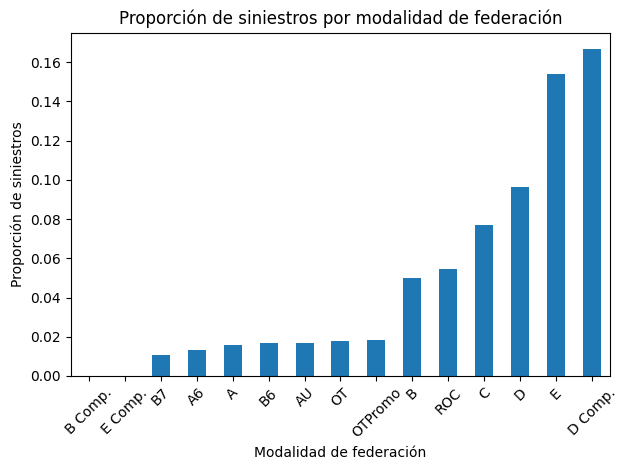

In [41]:
df_model.groupby("modalidad")["target"].mean().sort_values().plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Proporción de siniestros por modalidad de federación")
plt.xlabel("Modalidad de federación")
plt.ylabel("Proporción de siniestros")
plt.tight_layout()
plt.show();



In [42]:
# La variable modalidad representa el tipo de licencia o seguro contratado.
# Cada modalidad tiene diferentes coberturas (por ejemplo, ámbito nacional o internacional),
# lo que podría estar relacionado con la probabilidad de sufrir un siniestro.

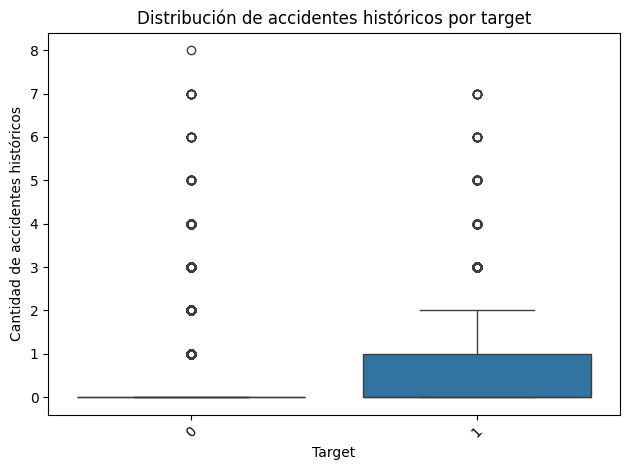

In [43]:
sns.boxplot(x="target", y="accidenteshistoricos", data=df_model)
plt.xticks(rotation=45)
plt.title("Distribución de accidentes históricos por target")
plt.xlabel("Target")
plt.ylabel("Cantidad de accidentes históricos")
plt.tight_layout()
plt.show();

In [44]:
df_model.groupby("accidenteshistoricos")["target"].mean()

accidenteshistoricos
0.0    0.034813
1.0    0.136642
2.0    0.194564
3.0    0.221763
4.0    0.311258
5.0    0.542857
6.0    0.560000
7.0    0.444444
8.0    0.000000
Name: target, dtype: float64

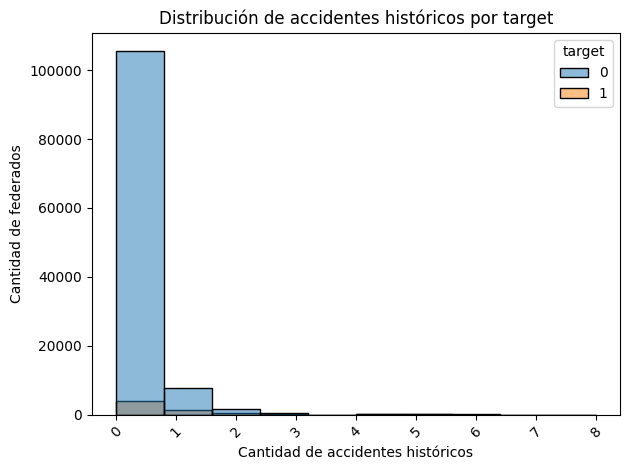

In [45]:
sns.histplot(data=df_model, x="accidenteshistoricos", hue="target", bins=10)
plt.xticks(rotation=45)
plt.title("Distribución de accidentes históricos por target")
plt.xlabel("Cantidad de accidentes históricos")
plt.ylabel("Cantidad de federados")
plt.tight_layout()
plt.show();

In [46]:
# Observamos que incluso en los casos con target=1, muchos valores de accidenteshistoricos son 0. 
# Esto indica que un federado puede sufrir un siniestro aunque no tenga antecedentes previos
# Lo cual es coherente con la naturaleza del problema

In [47]:
from sklearn.model_selection import GroupShuffleSplit  
# Utilizamos GroupShuffleSplit para asegurarnos de que los datos de un mismo federado (nsocio)
# no se dividan entre entrenamiento y prueba, evitando así data leakage.

X = df_model.drop(columns=["target","nsocio"])  
# Eliminamos el target y la columna nsocio: nsocio es un identificador, no debe ser feature.

y = df_model["target"]

groups = df_model["nsocio"]  
# nsocio se usa SOLO para agrupar (group split), no para entrenar el modelo.

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]